In [3]:
import gspread
import pandas as pd
import matplotlib.pyplot as plt
from google.oauth2.service_account import Credentials

## Pipeline A

In [5]:
SERVICE_ACCOUNT_FILE = '../../key/credentials.json'
SCOPES = ['https://www.googleapis.com/auth/spreadsheets',
          'https://www.googleapis.com/auth/drive']

creds = Credentials.from_service_account_file(SERVICE_ACCOUNT_FILE, scopes=SCOPES)
client = gspread.authorize(creds)

sheet = client.open('LLM Kula').worksheet('data_LLM')
data = sheet.get_all_values()

df = pd.DataFrame(data[2:], columns=data[1])
df.to_csv('../../raw_data/llm_qc.csv', index=False)

In [ ]:
df

,date,validator,scenario_category,sub_category,detail_category,mode,chat_id,sequence,eSimCSE,LLM,eSimCSE_dislike_reason,LLM_dislike_reason,Column 1
0,1/6/2026,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-11790357-3-1,1,Like,Dislike,,,
1,1/6/2026,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-11790357-3-1,2,Dislike,Like,tidak ada jawaban langsung kepada user,,
2,1/6/2026,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-2052378674-3-1,1,Dislike,Like,tidak sesuai FAQ,,
3,1/6/2026,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-2052378674-3-1,2,Like,Dislike,,tidak menjawab pertanyaan user,
4,1/6/2026,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-2052378674-3-1,4,Dislike,Like,robot masih menanyakan kendala user,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,1/15/2026,Azer,Logistik,alamat tidak terjangkau,bug,chat_bebas,,,,,,,
628,1/15/2026,Azer,Logistik,alamat tidak terjangkau,bug,chat_bebas,,,,,,,
629,1/15/2026,Azer,Logistik,alamat tidak terjangkau,bug,chat_bebas,,,,,,,
630,1/15/2026,Azer,Logistik,alamat tidak terjangkau,bug,chat_bebas,,,,,,,


In [ ]:
# copy the main df
df_clean = df.copy()

# change columns names into all lowercase
df_clean.columns = df_clean.columns.str.lower()

# date data type
df_clean['date'] = pd.to_datetime(
    df_clean['date']
)

# categorical data type
categorical_cols = [
    'validator', 'scenario_category', 'sub_category', 'detail_category', 'mode', 'esimcse', 'llm'
]

for col in categorical_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

# numeric data type
df_clean['sequence'] = df_clean['sequence'].replace('', 0).astype(int)

# the data
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 632 entries, 0 to 631
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    632 non-null    datetime64[ns]
 1   validator               632 non-null    category      
 2   scenario_category       632 non-null    category      
 3   sub_category            632 non-null    category      
 4   detail_category         632 non-null    category      
 5   mode                    632 non-null    category      
 6   chat_id                 632 non-null    object        
 7   sequence                632 non-null    int64         
 8   esimcse                 632 non-null    category      
 9   llm                     632 non-null    category      
 10  esimcse_dislike_reason  632 non-null    object        
 11  llm_dislike_reason      632 non-null    object        
 12  column 1                632 non-null    object    

In [ ]:
df_clean

,date,validator,scenario_category,sub_category,detail_category,mode,chat_id,sequence,esimcse,llm,esimcse_dislike_reason,llm_dislike_reason,column 1
0,2026-01-06,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-11790357-3-1,1,Like,Dislike,,,
1,2026-01-06,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-11790357-3-1,2,Dislike,Like,tidak ada jawaban langsung kepada user,,
2,2026-01-06,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-2052378674-3-1,1,Dislike,Like,tidak sesuai FAQ,,
3,2026-01-06,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-2052378674-3-1,2,Like,Dislike,,tidak menjawab pertanyaan user,
4,2026-01-06,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-2052378674-3-1,4,Dislike,Like,robot masih menanyakan kendala user,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,2026-01-15,Azer,Logistik,alamat tidak terjangkau,bug,chat_bebas,,0,,,,,
628,2026-01-15,Azer,Logistik,alamat tidak terjangkau,bug,chat_bebas,,0,,,,,
629,2026-01-15,Azer,Logistik,alamat tidak terjangkau,bug,chat_bebas,,0,,,,,
630,2026-01-15,Azer,Logistik,alamat tidak terjangkau,bug,chat_bebas,,0,,,,,


In [ ]:
esimcse_daily = (
    df_clean.groupby(['date', 'esimcse'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

llm_daily = (
    df_clean.groupby(['date','llm'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

C:\Users\ozy.prazuganda\AppData\Local\Temp\ipykernel_21700\3650651708.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby(['date', 'esimcse'])
C:\Users\ozy.prazuganda\AppData\Local\Temp\ipykernel_21700\3650651708.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby(['date','llm'])


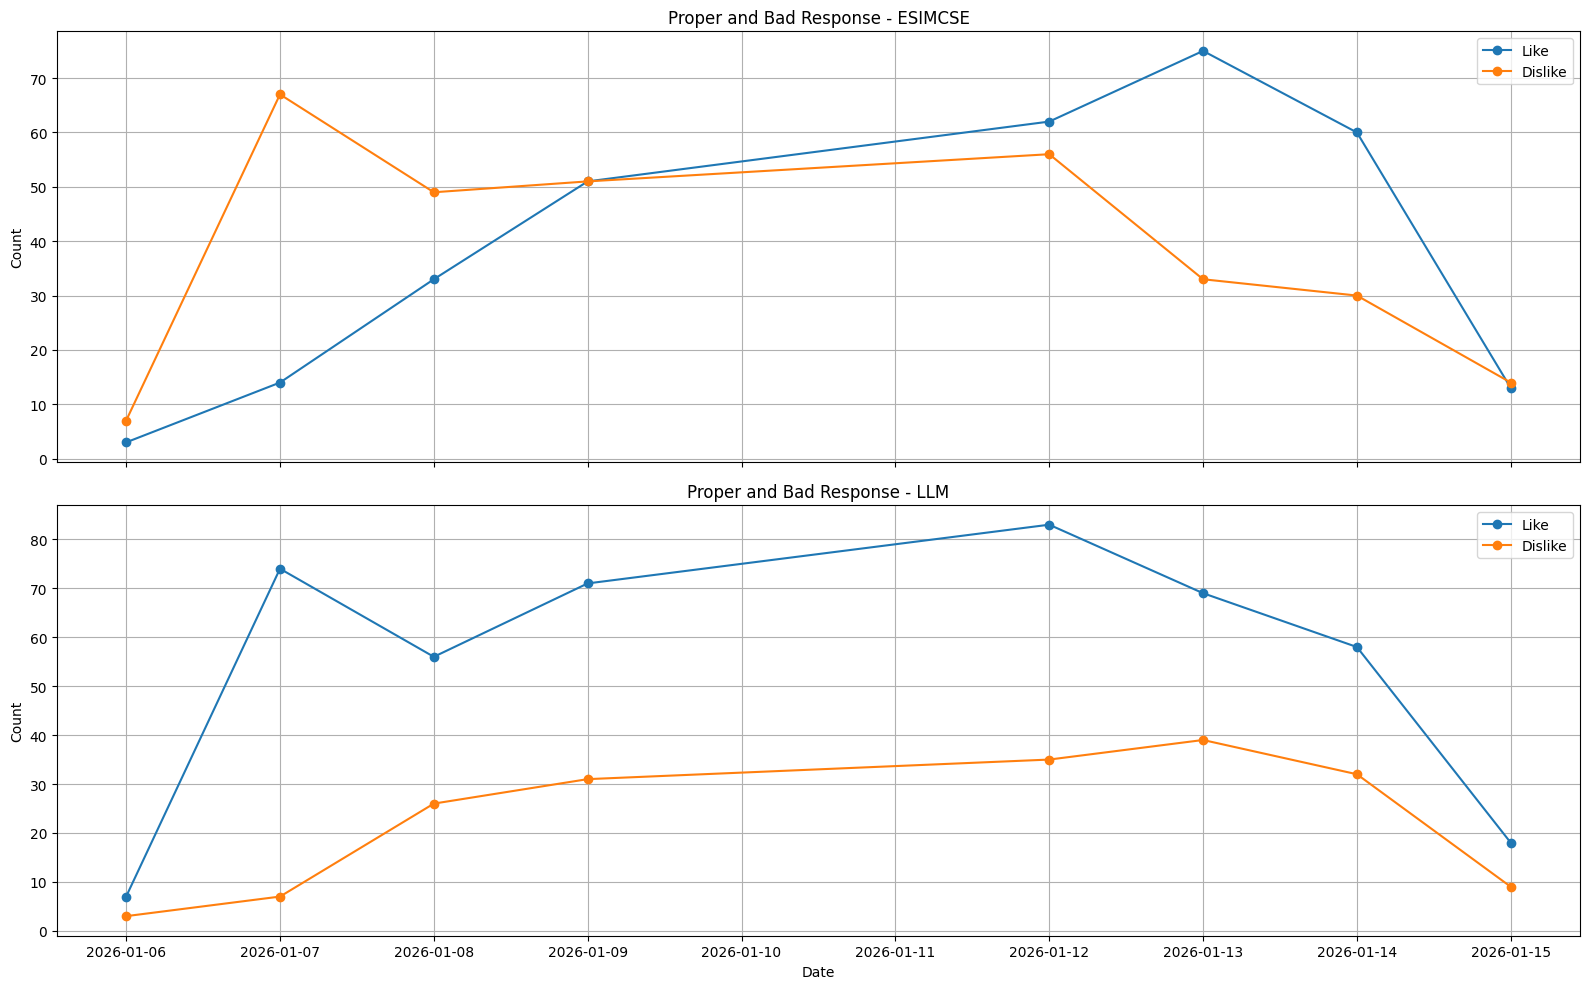

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# =========================
# ESIMCSE
# =========================
axes[0].plot(esimcse_daily.index, esimcse_daily.get('Like', 0), label='Like', marker='o')
axes[0].plot(esimcse_daily.index, esimcse_daily.get('Dislike', 0), label='Dislike', marker='o')

axes[0].set_title('Proper and Bad Response - ESIMCSE')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True)

# =========================
# LLM
# =========================
axes[1].plot(llm_daily.index, llm_daily.get('Like', 0), label='Like', marker='o')
axes[1].plot(llm_daily.index, llm_daily.get('Dislike', 0), label='Dislike', marker='o')

axes[1].set_title('Proper and Bad Response - LLM')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

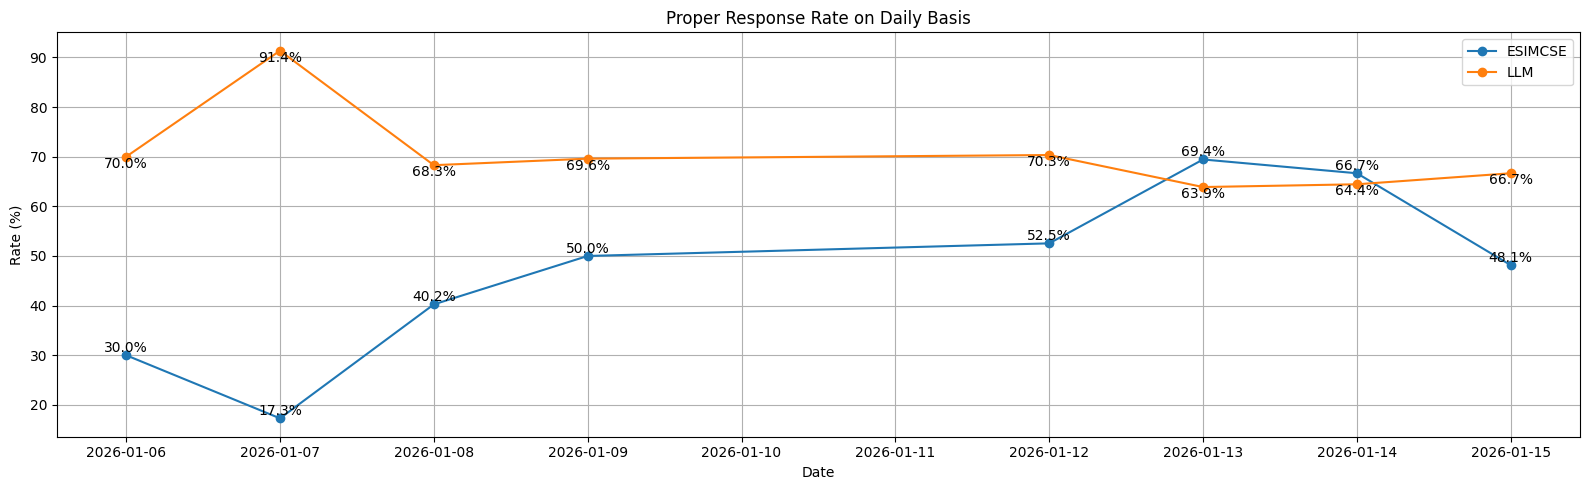

In [ ]:
# Total ESIMCSE
total_esimcse = esimcse_daily['Like'] + esimcse_daily['Dislike']
esimcse_daily['like_pct'] = (esimcse_daily['Like'] / total_esimcse) * 100

#Total LLM
total_llm = llm_daily['Like'] + llm_daily['Dislike']
llm_daily['like_pct'] = (llm_daily['Like'] / total_llm) * 100

plt.figure(figsize=(16, 5))

# Plot lines
plt.plot(
    esimcse_daily.index,
    esimcse_daily['like_pct'],
    marker='o',
    label='ESIMCSE'
)

plt.plot(
    llm_daily.index,
    llm_daily['like_pct'],
    marker='o',
    label='LLM'
)

# =========================
# ADD VALUE LABELS
# =========================
for x, y in zip(esimcse_daily.index, esimcse_daily['like_pct']):
    plt.text(
        x, y,
        f'{y:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

for x, y in zip(llm_daily.index, llm_daily['like_pct']):
    plt.text(
        x, y,
        f'{y:.1f}%',
        ha='center',
        va='top',
        fontsize=10
    )

# Styling
plt.title('Proper Response Rate on Daily Basis')
plt.ylabel('Rate (%)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

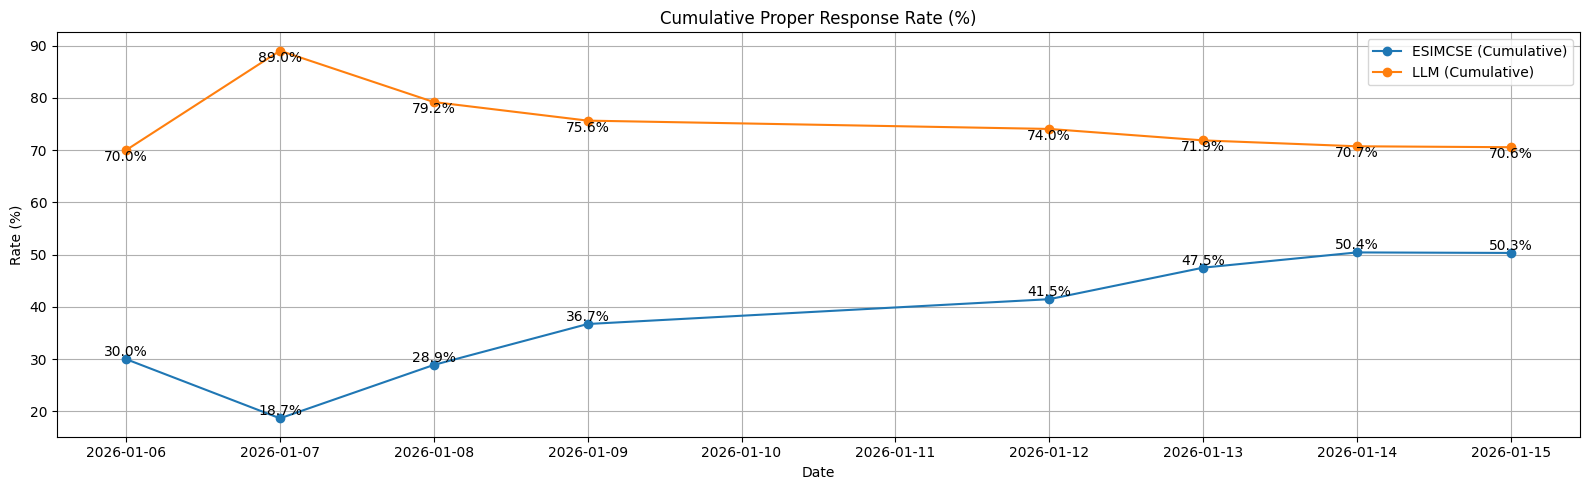

In [ ]:
# =========================
# CUMULATIVE ESIMCSE
# =========================
esimcse_daily['cum_like'] = esimcse_daily['Like'].cumsum()
esimcse_daily['cum_total'] = total_esimcse.cumsum()
esimcse_daily['cum_like_pct'] = (
    esimcse_daily['cum_like'] / esimcse_daily['cum_total']
) * 100


# =========================
# CUMULATIVE LLM
# =========================
llm_daily['cum_like'] = llm_daily['Like'].cumsum()
llm_daily['cum_total'] = total_llm.cumsum()
llm_daily['cum_like_pct'] = (
    llm_daily['cum_like'] / llm_daily['cum_total']
) * 100

plt.figure(figsize=(16, 5))

plt.plot(
    esimcse_daily.index,
    esimcse_daily['cum_like_pct'],
    marker='o',
    label='ESIMCSE (Cumulative)'
)

plt.plot(
    llm_daily.index,
    llm_daily['cum_like_pct'],
    marker='o',
    label='LLM (Cumulative)'
)

# Value labels
for x, y in zip(esimcse_daily.index, esimcse_daily['cum_like_pct']):
    plt.text(x, y, f'{y:.1f}%', ha='center', va='bottom', fontsize=10)

for x, y in zip(llm_daily.index, llm_daily['cum_like_pct']):
    plt.text(x, y, f'{y:.1f}%', ha='center', va='top', fontsize=10)

plt.title('Cumulative Proper Response Rate (%)')
plt.ylabel('Rate (%)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
